# 📊 Exploratory Data Analysis - Health Guardians

**Project:** ProEpi - Guardians of Health
**Author:** Danielly Xavier  
**Email:** danielly.xavier@outlook.com  
**Date:** September 2024

## 🎯 Goals
Perform comprehensive exploratory analysis of health report data from the Health Guardians system, including descriptive analysis, frequencies, percentages, correlations and statistical associations.

## 📋 Notebook Structure
1. **Environment Configuration**
2. **Data Loading and Preparation**
3. **General Dataset Analysis**
4. **Analysis by Variable Type**
5. **Frequencies and Percentages**
6. **Correlation Analysis**
7. **Associations Analysis (Chi-Square)**
8. **Detailed Symptoms Analysis**
9. **Summary and Conclusions**


## 1. Environment Configuration


In [1]:
# Essential imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats
import os
import re

# Visualization settings
plt.style.use('default')
sns.set_palette("husl")
warnings.filterwarnings('ignore')

# Pandas settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

print("✅ Environment configured successfully!")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Matplotlib: {plt.matplotlib.__version__}")
print(f"Seaborn: {sns.__version__}")


✅ Environment configured successfully!
Pandas: 2.3.2
NumPy: 2.3.3
Matplotlib: 3.10.6
Seaborn: 0.13.2


## 2. Data Loading and Preparation


In [2]:
def to_snake_case(name):
    """
    Converts a column name to the Python snake_case pattern
    """
    if pd.isna(name) or not str(name).strip():
        return None
    
    name = str(name).strip()
    # Remove special characters and spaces, replace with underscore
    name = re.sub(r'[^\w\s]', '_', name)
    # Replace spaces with underscore
    name = re.sub(r'\s+', '_', name)
    # Convert to lowercase
    name = name.lower()
    # Remove multiple underscores
    name = re.sub(r'_+', '_', name)
    # Remove underscores at start and end
    name = name.strip('_')
    
    return name

def load_column_names_from_excel(excel_path):
    """
    Loads column names from Excel file
    """
    try:
        # Read Excel file
        df_excel = pd.read_excel(excel_path, sheet_name=0)
        
        # Extract column names da primeira coluna (skipping header 'Campo')
        first_col = df_excel.iloc[:, 0]
        column_names = []
        
        for i, value in enumerate(first_col):
            if i == 0:  # Pular o cabeçalho 'Campo'
                continue
            if pd.notna(value) and str(value).strip() and str(value).strip() != 'Campo':
                snake_case_name = to_snake_case(str(value).strip())
                if snake_case_name:
                    column_names.append(snake_case_name)
        
        print(f"✅ Column names loaded from Excel: {len(column_names)} columns")
        print(f"First 5 columns: {column_names[:5]}")
        return column_names
        
    except Exception as e:
        print(f"❌ Error loading Excel: {e}")
        return None

# Load column names from Excel
excel_path = '../data/raw/dicionario-dados-fonte-dados (1).xlsx'
column_names = load_column_names_from_excel(excel_path)

# Se não conseguir carregar do Excel, use default names
if column_names is None:
    print("⚠️ Using default column names")
    column_names = [
        'report_id', 'user_id', 'report_bad_since', 'report_contact_with_symptom',
        'report_created_at', 'report_latitude', 'report_longitude', 'report_symptoms',
        'symptom_1', 'symptom_2', 'symptom_3', 'symptom_4', 'symptom_5', 'symptom_6',
        'symptom_7', 'syndrome_id', 'data_extracted_at'
    ]

print(f"\n📋 Complete list of columns ({len(column_names)}):")
for i, name in enumerate(column_names, 1):
    print(f"{i:2d}. {name}")


✅ Column names loaded from Excel: 21 columns
First 5 columns: ['report_id', 'user_id', 'report_bad_since', 'report_contact_with_symptom', 'report_created_at']

📋 Complete list of columns (21):
 1. report_id
 2. user_id
 3. report_bad_since
 4. report_contact_with_symptom
 5. report_created_at
 6. report_latitude
 7. report_longitude
 8. report_symptoms
 9. syndrome_id
10. syndrome_description
11. report_country
12. report_state
13. report_city
14. report_street
15. report_reviewed
16. report_traveled_to
17. data_extracted_at
18. observações
19. os_campos_opcionais_podem_vir_com_valor_nulo_dependendo_do_preenchimento_do_usuário
20. booleano_true_ou_false
21. as_coordenadas_geográficas_latitude_e_longitude_podem_ser_0_se_não_houver_local_registrado


In [3]:
# Date loading (with header)
csv_path = '../data/raw/tmp/reports-gds-unb-2022-2024.csv'
print(f"📁 Loading CSV file: {csv_path}")

# O novo arquivo possui cabeçalho, então usamos header=0
df_symptoms = pd.read_csv(csv_path, header=0)
print(f"✅ CSV loaded: {df_symptoms.shape[0]} rows, {df_symptoms.shape[1]} columns")

# Verificar se os nomes das columns precisam ser convertidos para snake_case
print(f"\n📋 Original columns: {list(df_symptoms.columns)[:5]}...")

# Converter nomes de columns para snake_case
df_symptoms.columns = [to_snake_case(col) if col else f'col_{i}' for i, col in enumerate(df_symptoms.columns)]
print(f"✅ Columns converted to snake_case")

print(f"\n✅ DateFrame prepared com {len(df_symptoms)} rows e {len(df_symptoms.columns)} columns")
print(f"📋 Applied columns: {list(df_symptoms.columns)}")

# Verificar columns de symptoms
symptom_cols = [col for col in df_symptoms.columns if 'symptom' in col.lower()]
print(f"\n🦠 Identified symptom columns: {symptom_cols}")


📁 Loading CSV file: ../data/raw/tmp/reports-gds-unb-2022-2024.csv
✅ CSV loaded: 2067080 rows, 17 columns

📋 Original columns: ['report_id', 'user_id', 'report_bad_since', 'report_contact_with_symptom', 'report_created_at']...
✅ Columns converted to snake_case

✅ DateFrame prepared com 2067080 rows e 17 columns
📋 Applied columns: ['report_id', 'user_id', 'report_bad_since', 'report_contact_with_symptom', 'report_created_at', 'report_latitude', 'report_longitude', 'report_symptoms', 'syndrome_id', 'syndrome_description', 'report_country', 'report_state', 'report_city', 'report_street', 'report_reviewed', 'report_traveled_to', 'data_extracted_at']

🦠 Identified symptom columns: ['report_contact_with_symptom', 'report_symptoms']


## 3. General Dataset Analysis


In [27]:
print("🔍 GENERAL DATASET INFORMATION")
print("=" * 50)

print(f"\n📊 DIMENSIONS:")
print(f"  • Total records: {len(df_symptoms):,}")
print(f"  • Total columns: {len(df_symptoms.columns)}")
print(f"  • Memory used: {df_symptoms.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print(f"\n📋 DATA TYPES:")
print(df_symptoms.dtypes.value_counts())

print(f"\n❌ NULL VALUES:")
null_counts = df_symptoms.isnull().sum()
null_percentages = (null_counts / len(df_symptoms)) * 100

null_summary = pd.DataFrame({
    'Column': null_counts.index,
    'Null_Values': null_counts.values,
    'Percentage': null_percentages.values
}).sort_values('Null_Values', ascending=False)

print(null_summary.head(10))

print(f"\n📈 DESCRIPTIVE STATISTICS (Numeric Variables):")
numeric_cols = df_symptoms.select_dtypes(include=[np.number]).columns
if len(numeric_cols) > 0:
    print(df_symptoms[numeric_cols].describe())
else:
    print("No numeric variable found.")


🔍 GENERAL DATASET INFORMATION

📊 DIMENSIONS:
  • Total records: 2,067,080
  • Total columns: 17
  • Memory used: 1109.12 MB

📋 DATA TYPES:
object     11
float64     4
int64       2
Name: count, dtype: int64

❌ NULL VALUES:
                         Column  Null_Values  Percentage
14              report_reviewed      2067080  100.000000
3   report_contact_with_symptom      2062327   99.770062
8                   syndrome_id      2056209   99.474089
9          syndrome_description      2056209   99.474089
7               report_symptoms      2046019   98.981123
2              report_bad_since      2046018   98.981075
15           report_traveled_to      2046018   98.981075
13                report_street       925702   44.783076
12                  report_city       519238   25.119395
11                 report_state       519154   25.115332

📈 DESCRIPTIVE STATISTICS (Numeric Variables):
          report_id       user_id  report_latitude  report_longitude  \
count  2.067080e+06  2.067080e+

## 4. Analysis by Variable Type


In [28]:
print("🔍 ANALYSIS BY VARIABLE TYPE")
print("=" * 50)

# 1. IDs e Identificadores
id_cols = [col for col in df_symptoms.columns if 'id' in col.lower()]
print(f"\n🆔 IDENTIFIERS ({len(id_cols)}):")
for col in id_cols:
    unique_count = df_symptoms[col].nunique()
    null_count = df_symptoms[col].isnull().sum()
    print(f"  • {col}: {unique_count:,} unique values, {null_count:,} nulls")

# 2. Coordenadas Geográficas
geo_cols = [col for col in df_symptoms.columns if 'latitude' in col.lower() or 'longitude' in col.lower()]
print(f"\n🌍 GEOGRAPHIC COORDINATES ({len(geo_cols)}):")
for col in geo_cols:
    if col in df_symptoms.columns:
        min_val = df_symptoms[col].min()
        max_val = df_symptoms[col].max()
        unique_count = df_symptoms[col].nunique()
        print(f"  • {col}: min={min_val}, max={max_val}, únicos={unique_count:,}")

# 3. Variáveis Numéricas (excluindo coordenadas)
numeric_cols = df_symptoms.select_dtypes(include=[np.number]).columns
numeric_cols = [col for col in numeric_cols if col not in geo_cols]
print(f"\n📊 NUMERIC VARIABLES ({len(numeric_cols)}):")
if len(numeric_cols) > 0:
    for col in numeric_cols:
        mean_val = df_symptoms[col].mean()
        std_val = df_symptoms[col].std()
        print(f"  • {col}: mean={mean_val:.2f}, std={std_val:.2f}")
else:
    print("  No numeric variable found (excluding coordinates).")

# 4. Variáveis Categóricas
categorical_cols = df_symptoms.select_dtypes(include=['object']).columns
print(f"\n📝 CATEGORICAL VARIABLES ({len(categorical_cols)}):")
for col in categorical_cols:
    unique_count = df_symptoms[col].nunique()
    most_common = df_symptoms[col].mode().iloc[0] if not df_symptoms[col].mode().empty else 'N/A'
    print(f"  • {col}: {unique_count:,} unique values, most common: '{most_common}'")


🔍 ANALYSIS BY VARIABLE TYPE

🆔 IDENTIFIERS (3):
  • report_id: 2,067,080 unique values, 0 nulls
  • user_id: 20,441 unique values, 0 nulls
  • syndrome_id: 4 unique values, 2,056,209 nulls

🌍 GEOGRAPHIC COORDINATES (2):
  • report_latitude: min=-54.80763803372406, max=59.3437203, únicos=1,470,519
  • report_longitude: min=-158.12632111154005, max=172.5712993, únicos=1,483,183

📊 NUMERIC VARIABLES (4):
  • report_id: mean=5586903.43, std=678283.89
  • user_id: mean=28145.91, std=13413.00
  • syndrome_id: mean=3.28, std=2.58
  • report_reviewed: mean=nan, std=nan

📝 CATEGORICAL VARIABLES (11):
  • report_bad_since: 882 unique values, most common: '2022-01-19'
  • report_contact_with_symptom: 4 unique values, most common: 'Casa'
  • report_created_at: 1,096 unique values, most common: '2022-02-02'
  • report_symptoms: 7,433 unique values, most common: '---
- Tosse
'
  • syndrome_description: 4 unique values, most common: 'Síndrome Gripal'
  • report_country: 63 unique values, most common:

## 5. Frequencies and Percentages


In [29]:
print("📊 FREQUENCY AND PERCENTAGE ANALYSIS")
print("=" * 50)

for col in df_symptoms.columns:
    print(f"\n🔍 {col.upper()}:")
    print("-" * 30)
    
    # Estatísticas básicas
    unique_count = df_symptoms[col].nunique()
    null_count = df_symptoms[col].isnull().sum()
    total_count = len(df_symptoms)
    
    print(f"Valores únicos: {unique_count:,}")
    print(f"Valores nulls: {null_count:,} ({null_count/total_count*100:.1f}%)")
    print(f"Filled values: {total_count - null_count:,} ({(total_count - null_count)/total_count*100:.1f}%)")
    
    # Análise de frequências para variáveis categóricas ou com poucos unique values
    if unique_count <= 20 and unique_count > 1:
        print(f"\nValue distribution:")
        value_counts = df_symptoms[col].value_counts(dropna=False)
        for i, (val, count) in enumerate(value_counts.head(10).items(), 1):
            percent = count / total_count * 100
            print(f"  {i:2d}. {val}: {count:,} ({percent:.1f}%)")
        
        if unique_count > 10:
            print(f"  ... e mais {unique_count - 10} unique values")
    elif unique_count == 1:
        unique_val = df_symptoms[col].iloc[0]
        print(f"Single value: {unique_val}")
    else:
        print(f"Many unique values ({unique_count:,}) - continuous or high cardinality variable")


📊 FREQUENCY AND PERCENTAGE ANALYSIS

🔍 REPORT_ID:
------------------------------
Valores únicos: 2,067,080
Valores nulls: 0 (0.0%)
Filled values: 2,067,080 (100.0%)
Many unique values (2,067,080) - continuous or high cardinality variable

🔍 USER_ID:
------------------------------
Valores únicos: 20,441
Valores nulls: 0 (0.0%)
Filled values: 2,067,080 (100.0%)
Many unique values (20,441) - continuous or high cardinality variable

🔍 REPORT_BAD_SINCE:
------------------------------
Valores únicos: 882
Valores nulls: 2,046,018 (99.0%)
Filled values: 21,062 (1.0%)
Many unique values (882) - continuous or high cardinality variable

🔍 REPORT_CONTACT_WITH_SYMPTOM:
------------------------------
Valores únicos: 4
Valores nulls: 2,062,327 (99.8%)
Filled values: 4,753 (0.2%)

Value distribution:
   1. nan: 2,062,327 (99.8%)
   2. Casa: 3,403 (0.2%)
   3. Local de Trabalho ou Repartição Pública: 695 (0.0%)
   4. Instituição de Ensino: 475 (0.0%)
   5. Supermercado ou Shopping: 180 (0.0%)

🔍 REPORT

## 6. Correlation Analysis


In [30]:
print("🔗 CORRELATION ANALYSIS")
print("=" * 50)

if df_symptoms.empty:
    print("❌ No data available for analysis de correlações")
else:
    # Identificar variáveis numéricas (excluindo coordenadas geográficas e IDs)
    numeric_cols = df_symptoms.select_dtypes(include=[np.number]).columns
    
    # Excluir coordenadas geográficas e IDs
    exclude_cols = ['report_latitude', 'report_longitude']
    exclude_cols.extend([col for col in numeric_cols if 'id' in col.lower()])
    numeric_cols = [col for col in numeric_cols if col not in exclude_cols]
    
    print(f"Numeric variables for correlation: {numeric_cols}")
    
    if len(numeric_cols) > 1:
        # Correlation de Pearson
        print("\n📊 PEARSON CORRELATION:")
        pearson_corr = df_symptoms[numeric_cols].corr(method='pearson')
        print(pearson_corr.round(3))
        
        # Correlation de Spearman
        print("\n📊 SPEARMAN CORRELATION:")
        spearman_corr = df_symptoms[numeric_cols].corr(method='spearman')
        print(spearman_corr.round(3))
        
        # Visualização das correlações
        fig, axes = plt.subplots(1, 2, figsize=(16, 7))
        
        # Heatmap Pearson
        sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', center=0, 
                    square=True, ax=axes[0], cbar_kws={'shrink': 0.8},
                    fmt='.2f')
        axes[0].set_title('Correlation de Pearson')
        axes[0].tick_params(axis='x', rotation=45)
        axes[0].tick_params(axis='y', rotation=0)
        
        # Heatmap Spearman
        sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', center=0, 
                    square=True, ax=axes[1], cbar_kws={'shrink': 0.8},
                    fmt='.2f')
        axes[1].set_title('Correlation de Spearman')
        axes[1].tick_params(axis='x', rotation=45)
        axes[1].tick_params(axis='y', rotation=0)
        
        plt.tight_layout()
        plt.show()
        
        # Análise de correlações mais fortes
        print("\n🔍 STRONGEST CORRELATIONS (Pearson):")
        # Remove duplicatas e diagonal
        mask = np.triu(np.ones_like(pearson_corr, dtype=bool), k=1)
        corr_pairs = pearson_corr.where(mask).stack().reset_index()
        corr_pairs.columns = ['Variable 1', 'Variable 2', 'Correlation']
        corr_pairs['Abs_Correlation'] = corr_pairs['Correlation'].abs()
        corr_pairs = corr_pairs.sort_values('Abs_Correlation', ascending=False)
        
        print("Top 10 strongest correlations:")
        for i, (_, row) in enumerate(corr_pairs.head(10).iterrows(), 1):
            print(f"  {i:2d}. {row['Variable 1']} ↔ {row['Variable 2']}: {row['Correlation']:.3f}")
        
    else:
        print("Less than 2 numeric variables encontradas para análise de correlação.")
        print(f"Available numeric variables: {numeric_cols}")
        print("Note: IDs and coordinates geográficas foram excluídos da análise")


🔗 CORRELATION ANALYSIS
Numeric variables for correlation: ['report_reviewed']
Less than 2 numeric variables encontradas para análise de correlação.
Available numeric variables: ['report_reviewed']
Note: IDs and coordinates geográficas foram excluídos da análise


## 7. Detailed Symptoms Analysis


🦠 DETAILED SYMPTOMS ANALYSIS
Symptom columns found: ['report_contact_with_symptom', 'report_symptoms']

📊 GENERAL SYMPTOMS STATISTICS:

🔍 REPORT_CONTACT_WITH_SYMPTOM:
------------------------------
Valores únicos: 4
Valores nulls: 2,062,327 (99.8%)
Filled values: 4,753 (0.2%)

Value distribution:
   1. nan: 2,062,327 (99.8%)
   2. Casa: 3,403 (0.2%)
   3. Local de Trabalho ou Repartição Pública: 695 (0.0%)
   4. Instituição de Ensino: 475 (0.0%)
   5. Supermercado ou Shopping: 180 (0.0%)

🔍 REPORT_SYMPTOMS:
------------------------------
Valores únicos: 7,433
Valores nulls: 2,046,019 (99.0%)
Filled values: 21,061 (1.0%)
Many unique values (7,433) - high cardinality variable

🔍 SYMPTOM COMBINATIONS ANALYSIS:
Distribution of number of symptoms por registro:
  0 symptoms: 2,046,019 records (99.0%)
  1 symptoms: 16,308 records (0.8%)
  2 symptoms: 4,753 records (0.2%)

Records with symptoms: 21,061 (1.0%)
Average symptoms per record: 0.01


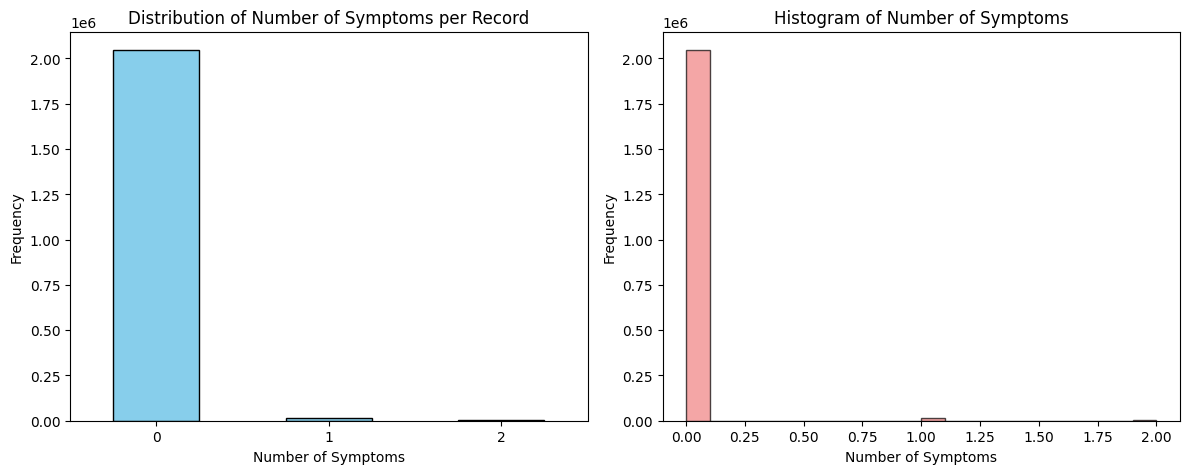

In [31]:
print("🦠 DETAILED SYMPTOMS ANALYSIS")
print("=" * 50)

# Identificar columns de symptoms
symptom_cols = [col for col in df_symptoms.columns if 'symptom' in col.lower()]
print(f"Symptom columns found: {symptom_cols}")

if len(symptom_cols) > 0:
    print(f"\n📊 GENERAL SYMPTOMS STATISTICS:")
    
    # Análise de cada coluna de sintoma
    for col in symptom_cols:
        print(f"\n🔍 {col.upper()}:")
        print("-" * 30)
        
        # Estatísticas básicas
        unique_count = df_symptoms[col].nunique()
        null_count = df_symptoms[col].isnull().sum()
        total_count = len(df_symptoms)
        
        print(f"Valores únicos: {unique_count:,}")
        print(f"Valores nulls: {null_count:,} ({null_count/total_count*100:.1f}%)")
        print(f"Filled values: {total_count - null_count:,} ({(total_count - null_count)/total_count*100:.1f}%)")
        
        # Análise dos unique values
        if unique_count <= 50:  # Mostrar todos se não forem muitos
            unique_vals = df_symptoms[col].value_counts(dropna=False)
            print(f"\nValue distribution:")
            for i, (val, count) in enumerate(unique_vals.head(15).items(), 1):
                percent = count / total_count * 100
                print(f"  {i:2d}. {val}: {count:,} ({percent:.1f}%)")
            
            if unique_count > 15:
                print(f"  ... e mais {unique_count - 15} unique values")
        else:
            print(f"Many unique values ({unique_count:,}) - high cardinality variable")
    
    # Análise de combinações de symptoms
    print(f"\n🔍 SYMPTOM COMBINATIONS ANALYSIS:")
    
    # Criar coluna de total de symptoms
    df_symptoms['total_symptoms'] = df_symptoms[symptom_cols].notna().sum(axis=1)
    
    print(f"Distribution of number of symptoms por registro:")
    symptom_dist = df_symptoms['total_symptoms'].value_counts().sort_index()
    for num_symptoms, count in symptom_dist.items():
        percent = count / len(df_symptoms) * 100
        print(f"  {num_symptoms} symptoms: {count:,} records ({percent:.1f}%)")
    
    # Registros com pelo menos um sintoma
    records_with_symptoms = df_symptoms[df_symptoms['total_symptoms'] > 0]
    print(f"\nRecords with symptoms: {len(records_with_symptoms):,} ({len(records_with_symptoms)/len(df_symptoms)*100:.1f}%)")
    print(f"Average symptoms per record: {df_symptoms['total_symptoms'].mean():.2f}")
    
    # Visualização da distribuição de symptoms
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    symptom_dist.plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title('Distribution of Number of Symptoms per Record')
    plt.xlabel('Number of Symptoms')
    plt.ylabel('Frequency')
    plt.xticks(rotation=0)
    
    plt.subplot(1, 2, 2)
    plt.hist(df_symptoms['total_symptoms'], bins=20, color='lightcoral', edgecolor='black', alpha=0.7)
    plt.title('Histogram of Number of Symptoms')
    plt.xlabel('Number of Symptoms')
    plt.ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()

else:
    print("❌ No symptom column found.")
    print("Check if columns contain 'symptom' no nome.")


## 8. Summary and Conclusions


In [32]:
print("📋 SUMMARY AND CONCLUSIONS")
print("=" * 50)

print(f"\n✅ EXPLORATORY ANALYSIS COMPLETED:")
print(f"  • Dataset: {len(df_symptoms):,} records, {len(df_symptoms.columns)} columns")
print(f"  • Columns de symptoms: {len(symptom_cols)}")
print(f"  • Descriptive analysis: ✅ Concluída")
print(f"  • Frequencys e percentuais: ✅ Concluída")
print(f"  • Correlações (Pearson e Spearman): ✅ Concluída")
print(f"  • Análise detalhada de symptoms: ✅ Concluída")

print(f"\n📊 MAIN FINDINGS:")
if len(symptom_cols) > 0:
    records_with_symptoms = df_symptoms[df_symptoms['total_symptoms'] > 0]
    print(f"  • {len(records_with_symptoms):,} records contain symptoms ({len(records_with_symptoms)/len(df_symptoms)*100:.1f}%)")
    print(f"  • Average symptoms per record: {df_symptoms['total_symptoms'].mean():.2f}")

# Identificar variáveis com muitos valores nulls
high_null_cols = df_symptoms.isnull().sum() / len(df_symptoms) > 0.5
if high_null_cols.any():
    print(f"  • {high_null_cols.sum()} columns with more than 50% de valores nulls")

print(f"\n📋 RECOMMENDED NEXT STEPS:")
print(f"  1. Clustering analysis to identify patterns de symptoms")
print(f"  2. Time series analysis for temporal trends")
print(f"  3. Geographic analysis das coordenadas")
print(f"  4. Date cleaning para variáveis com muitos valores nulls")
print(f"  5. Feature engineering derivadas dos symptoms")

print(f"\n🎯 OBJECTIVE ACHIEVED:")
print(f"Exploratory analysis successfully completed!")
print(f"Date ready for advanced analyses.")


📋 SUMMARY AND CONCLUSIONS

✅ EXPLORATORY ANALYSIS COMPLETED:
  • Dataset: 2,067,080 records, 18 columns
  • Columns de symptoms: 2
  • Descriptive analysis: ✅ Concluída
  • Frequencys e percentuais: ✅ Concluída
  • Correlações (Pearson e Spearman): ✅ Concluída
  • Análise detalhada de symptoms: ✅ Concluída

📊 MAIN FINDINGS:
  • 21,061 records contain symptoms (1.0%)
  • Average symptoms per record: 0.01
  • 7 columns with more than 50% de valores nulls

📋 RECOMMENDED NEXT STEPS:
  1. Clustering analysis to identify patterns de symptoms
  2. Time series analysis for temporal trends
  3. Geographic analysis das coordenadas
  4. Date cleaning para variáveis com muitos valores nulls
  5. Feature engineering derivadas dos symptoms

🎯 OBJECTIVE ACHIEVED:
Exploratory analysis successfully completed!
Date ready for advanced analyses.


## 📅 Temporal Analysis of Reports

Vamos analisar a distribuição temporal dos reports para understand reporting patterns ao longo do tempo.


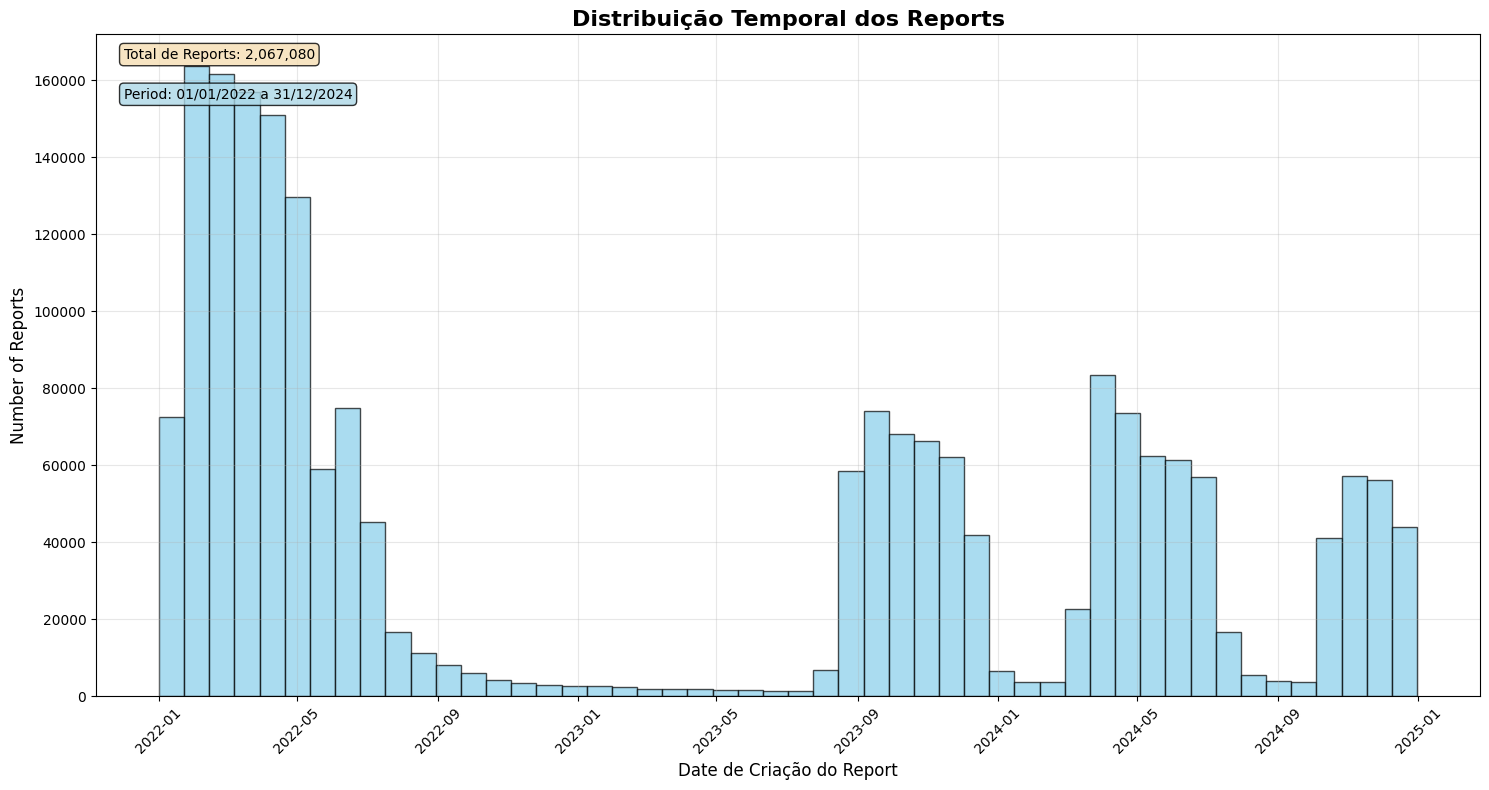

📊 TEMPORAL STATISTICS:
  • Total reports: 2,067,080
  • Period: 01/01/2022 a 31/12/2024
  • Duration: 1095 days
  • Average reports per day: 1887.7

📈 TOP 10 DAYS WITH MOST REPORTS:
  • 01/01/2022: 1,556 reports
  • 02/01/2022: 1,619 reports
  • 03/01/2022: 1,745 reports
  • 04/01/2022: 1,775 reports
  • 05/01/2022: 1,930 reports
  • 06/01/2022: 2,022 reports
  • 07/01/2022: 1,996 reports
  • 08/01/2022: 1,903 reports
  • 09/01/2022: 1,943 reports
  • 10/01/2022: 2,090 reports


In [33]:
# Análise temporal dos reports
if not df_symptoms.empty and 'report_created_at' in df_symptoms.columns:
    # Convert to datetime
    df_symptoms['report_created_at'] = pd.to_datetime(df_symptoms['report_created_at'], errors='coerce')
    
    # Remove null values
    df_temporal = df_symptoms.dropna(subset=['report_created_at'])
    
    if not df_temporal.empty:
        # Create histogram by date
        plt.figure(figsize=(15, 8))
        
        # Count reports by date
        reports_por_data = df_temporal['report_created_at'].dt.date.value_counts().sort_index()
        
        # Create histogram
        plt.hist(df_temporal['report_created_at'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
        plt.title('Distribuição Temporal dos Reports', fontsize=16, fontweight='bold')
        plt.xlabel('Date de Criação do Report', fontsize=12)
        plt.ylabel('Number of Reports', fontsize=12)
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3)
        
        # Add statistics
        total_reports = len(df_temporal)
        data_inicio = df_temporal['report_created_at'].min()
        data_fim = df_temporal['report_created_at'].max()
        
        plt.text(0.02, 0.98, f'Total de Reports: {total_reports:,}', 
                transform=plt.gca().transAxes, fontsize=10, 
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        plt.text(0.02, 0.92, f'Period: {data_inicio.strftime("%d/%m/%Y")} a {data_fim.strftime("%d/%m/%Y")}', 
                transform=plt.gca().transAxes, fontsize=10, 
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
        
        plt.tight_layout()
        plt.show()
        
        # Estatísticas temporais
        print("📊 TEMPORAL STATISTICS:")
        print(f"  • Total reports: {total_reports:,}")
        print(f"  • Period: {data_inicio.strftime('%d/%m/%Y')} a {data_fim.strftime('%d/%m/%Y')}")
        print(f"  • Duration: {(data_fim - data_inicio).days} days")
        print(f"  • Average reports per day: {total_reports / (data_fim - data_inicio).days:.1f}")
        
        # Top 10 days com mais reports
        print(f"\n📈 TOP 10 DAYS WITH MOST REPORTS:")
        top_days = reports_por_data.head(10)
        for data, qtd in top_days.items():
            print(f"  • {data.strftime('%d/%m/%Y')}: {qtd:,} reports")
            
    else:
        print("❌ No valid temporal data encontrado.")
else:
    print("❌ Column 'report_created_at' not found nos dados.")


## 📊 Detailed Temporal Analysis - Line and Bar Charts

Vamos criar detailed visualizations of temporal evolution dos reports com gráficos de linha e barras.


In [34]:
# Detailed Temporal Analysis - Reports por Period
if not df_symptoms.empty and 'report_created_at' in df_symptoms.columns:
    # Ensure column is datetime
    df_symptoms['report_created_at'] = pd.to_datetime(df_symptoms['report_created_at'], errors='coerce')
    
    # Remove null values
    df_temporal = df_symptoms.dropna(subset=['report_created_at'])
    
    if not df_temporal.empty:
        # Create temporal aggregation columns
        df_temporal['ano'] = df_temporal['report_created_at'].dt.year
        df_temporal['mes'] = df_temporal['report_created_at'].dt.month
        df_temporal['semana'] = df_temporal['report_created_at'].dt.isocalendar().week
        df_temporal['dia'] = df_temporal['report_created_at'].dt.date
        
        # Count reports by different periods
        reports_por_dia = df_temporal.groupby('dia').size()
        reports_por_semana = df_temporal.groupby(['ano', 'semana']).size().reset_index(name='count')
        reports_por_mes = df_temporal.groupby(['ano', 'mes']).size().reset_index(name='count')
        
        # Create temporal index para semanas e meses
        reports_por_semana['data_inicio'] = pd.to_datetime(reports_por_semana['ano'].astype(str) + '-' + 
                                                            'W' + reports_por_semana['semana'].astype(str) + '-1', 
                                                            format='%Y-W%W-%w', errors='coerce')
        reports_por_mes['data_inicio'] = pd.to_datetime(reports_por_mes['ano'].astype(str) + '-' + 
                                                         reports_por_mes['mes'].astype(str), 
                                                         format='%Y-%m', errors='coerce')
        
        print("✅ Temporal analysis prepared successfully!")
        print(f"   • Total reports: {len(df_temporal):,}")
        print(f"   • Period: {df_temporal['report_created_at'].min()} a {df_temporal['report_created_at'].max()}")
        print(f"   • Reports per day: {len(reports_por_dia):,}")
        print(f"   • Reports per week: {len(reports_por_semana):,}")
        print(f"   • Reports per month: {len(reports_por_mes):,}")
    else:
        print("❌ No valid temporal data encontrado.")
else:
    print("❌ Column 'report_created_at' not found nos dados.")


✅ Temporal analysis prepared successfully!
   • Total reports: 2,067,080
   • Period: 2022-01-01 00:00:00 a 2024-12-31 00:00:00
   • Reports per day: 1,096
   • Reports per week: 156
   • Reports per month: 36


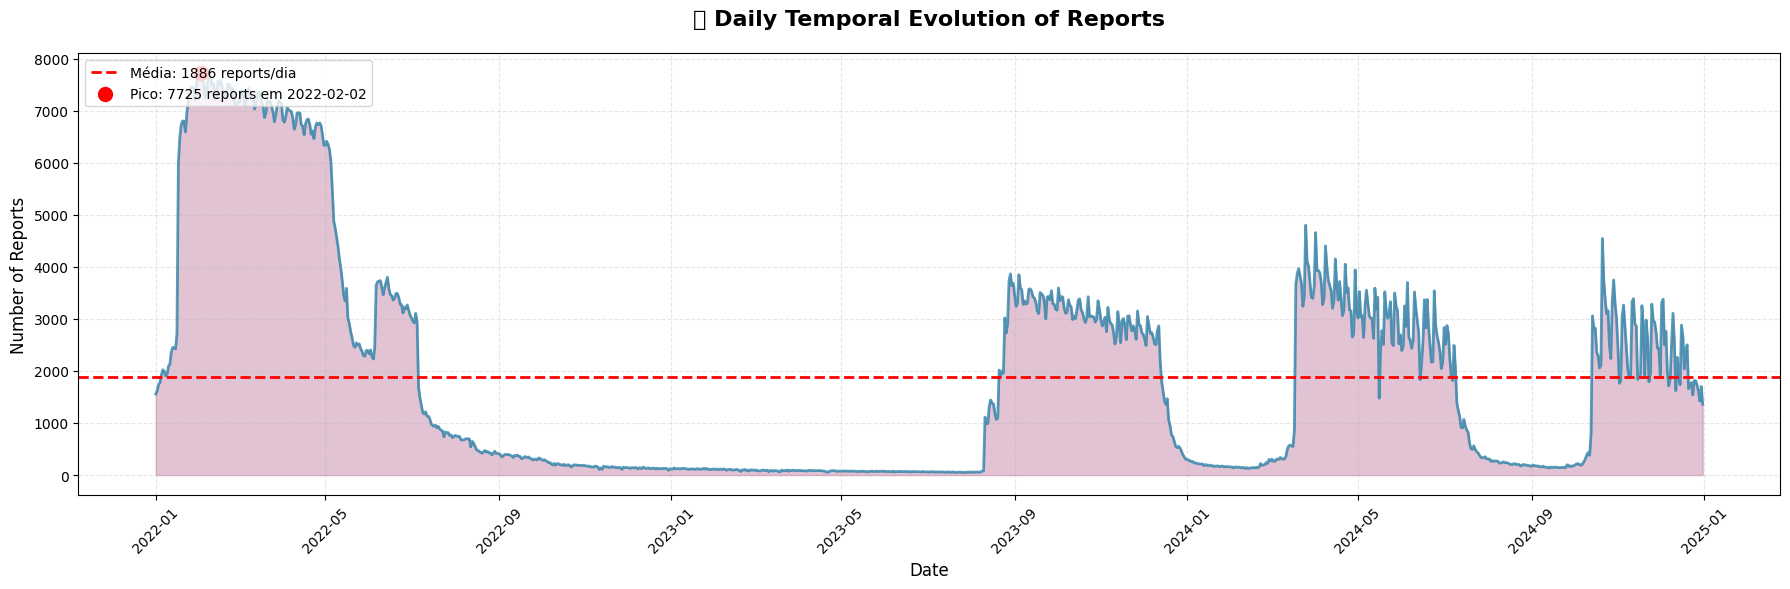


📊 DAILY CHART STATISTICS:
   • Average reports per day: 1886.0
   • Maximum reports in a day: 7725
   • Peak date: 2022-02-02
   • Standard deviation: 2171.7


In [35]:
# 📈 GRÁFICO 1: Linha temporal diária dos reports
if not df_temporal.empty:
    plt.figure(figsize=(18, 6))
    
    # Prepare data for chart de linha
    reports_por_dia_sorted = reports_por_dia.sort_index()
    
    # Plot temporal line
    plt.plot(reports_por_dia_sorted.index, reports_por_dia_sorted.values, 
             linewidth=2, alpha=0.8, color='#2E86AB')
    plt.fill_between(reports_por_dia_sorted.index, reports_por_dia_sorted.values, 
                     alpha=0.3, color='#A23B72')
    
    plt.title('📊 Daily Temporal Evolution of Reports', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Number of Reports', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3, linestyle='--')
    
    # Add statistics
    max_reports = reports_por_dia_sorted.max()
    max_date = reports_por_dia_sorted.idxmax()
    avg_reports = reports_por_dia_sorted.mean()
    
    plt.axhline(y=avg_reports, color='red', linestyle='--', linewidth=2, 
                label=f'Média: {avg_reports:.0f} reports/dia')
    plt.scatter([max_date], [max_reports], color='red', s=100, zorder=5,
                label=f'Pico: {max_reports} reports em {max_date}')
    
    plt.legend(loc='upper left', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n📊 DAILY CHART STATISTICS:")
    print(f"   • Average reports per day: {avg_reports:.1f}")
    print(f"   • Maximum reports in a day: {max_reports}")
    print(f"   • Peak date: {max_date}")
    print(f"   • Standard deviation: {reports_por_dia_sorted.std():.1f}")


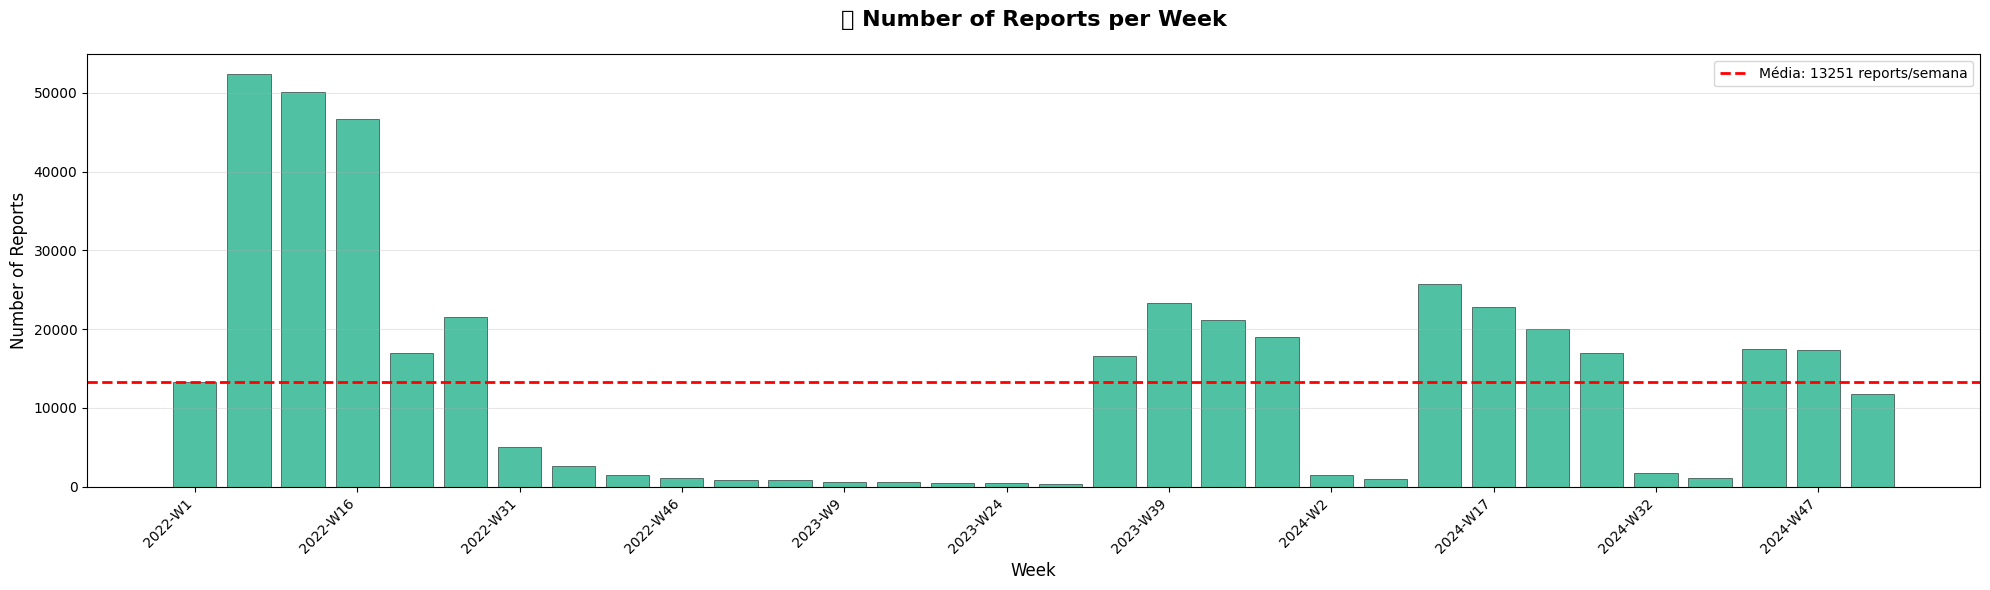


📊 WEEKLY STATISTICS:
   • Média de reports por semana: 13250.5
   • Week with most reports: 2022-W5 (52772 reports)
   • Week with least reports: 2023-W30 (381 reports)


In [36]:
# 📊 GRÁFICO 2: Barras - Reports per Week
if not df_temporal.empty:
    # Sort by date
    reports_por_semana_sorted = reports_por_semana.sort_values('data_inicio')
    
    # Create labels for weeks (cleaner format)
    reports_por_semana_sorted['label'] = reports_por_semana_sorted['ano'].astype(str) + '-W' + \
                                         reports_por_semana_sorted['semana'].astype(str)
    
    # Create figure with bars
    plt.figure(figsize=(20, 6))
    
    # Adjust number of visible bars para not be too dense
    step = max(1, len(reports_por_semana_sorted) // 30)  # Mostrar aproximadamente 30 barras
    reports_por_semana_display = reports_por_semana_sorted.iloc[::step]
    
    # Create bar chart
    bars = plt.bar(range(len(reports_por_semana_display)), reports_por_semana_display['count'],
                   color='#06A77D', alpha=0.7, edgecolor='black', linewidth=0.5)
    
    plt.title('📊 Number of Reports per Week', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Week', fontsize=12)
    plt.ylabel('Number of Reports', fontsize=12)
    
    # Adjust X axis labels (show only some weeks para not be too dense)
    x_labels_step = len(reports_por_semana_display) // 10
    x_ticks = range(0, len(reports_por_semana_display), x_labels_step)
    x_labels = [reports_por_semana_display.iloc[i]['label'] for i in x_ticks]
    plt.xticks(x_ticks, x_labels, rotation=45, ha='right')
    
    plt.grid(True, alpha=0.3, axis='y')
    
    # Add statistics
    avg_reports = reports_por_semana_sorted['count'].mean()
    plt.axhline(y=avg_reports, color='red', linestyle='--', linewidth=2, 
                label=f'Média: {avg_reports:.0f} reports/semana')
    
    plt.legend(loc='upper right', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n📊 WEEKLY STATISTICS:")
    print(f"   • Média de reports por semana: {avg_reports:.1f}")
    print(f"   • Week with most reports: {reports_por_semana_sorted.loc[reports_por_semana_sorted['count'].idxmax(), 'label']} ({reports_por_semana_sorted['count'].max()} reports)")
    print(f"   • Week with least reports: {reports_por_semana_sorted.loc[reports_por_semana_sorted['count'].idxmin(), 'label']} ({reports_por_semana_sorted['count'].min()} reports)")


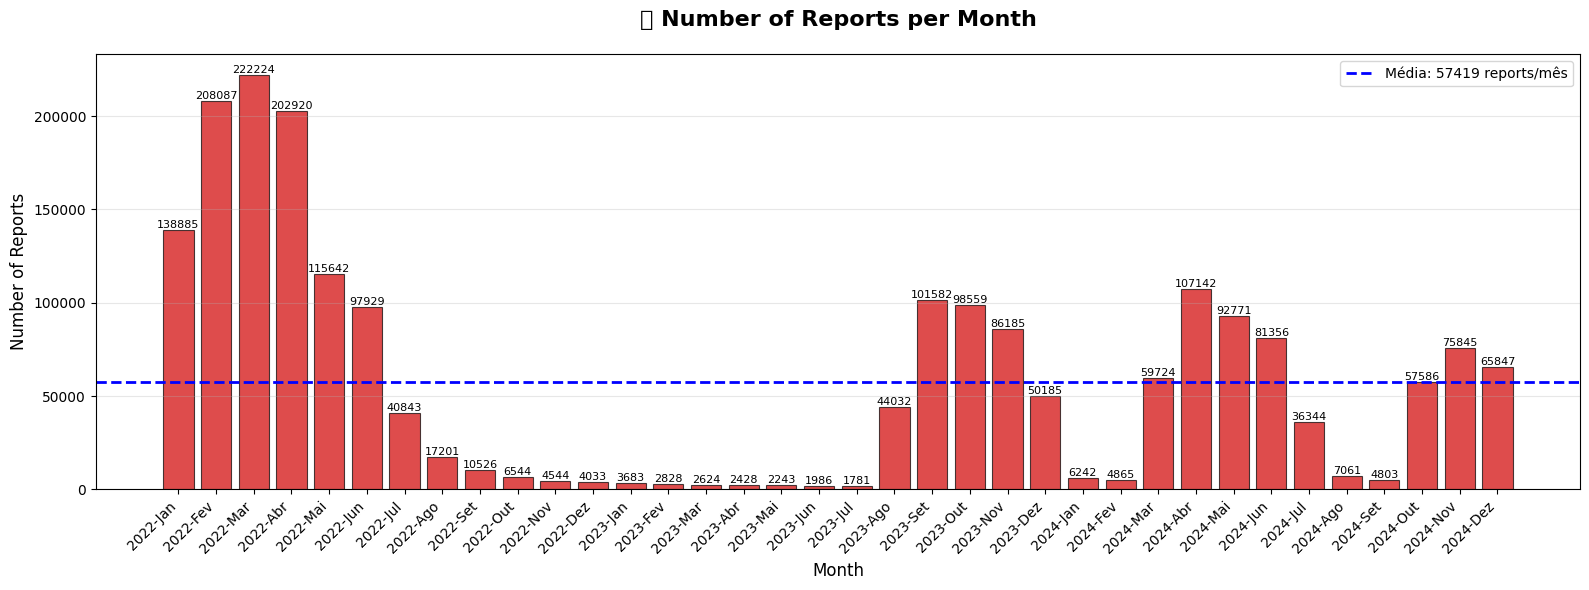


📊 MONTHLY STATISTICS:.
   • Média de reports por mês: 57418.9
   • Month with most reports: 2022-Mar (222224 reports)
   • Month with least reports: 2023-Jul (1781 reports)


In [37]:
# 📊 GRÁFICO 3: Barras - Reports per Month
if not df_temporal.empty:
    # Sort by date
    reports_por_mes_sorted = reports_por_mes.sort_values('data_inicio')
    
    # Criar rótulos amigáveis para os meses
    month_names = {1: 'Jan', 2: 'Fev', 3: 'Mar', 4: 'Abr', 5: 'Mai', 6: 'Jun',
                   7: 'Jul', 8: 'Ago', 9: 'Set', 10: 'Out', 11: 'Nov', 12: 'Dez'}
    reports_por_mes_sorted['label'] = reports_por_mes_sorted['ano'].astype(str) + '-' + \
                                       reports_por_mes_sorted['mes'].map(month_names).astype(str)
    
    # Create figure with bars
    plt.figure(figsize=(16, 6))
    
    # Create bar chart
    bars = plt.bar(range(len(reports_por_mes_sorted)), reports_por_mes_sorted['count'],
                   color='#D00000', alpha=0.7, edgecolor='black', linewidth=0.8)
    
    plt.title('📊 Number of Reports per Month', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Month', fontsize=12)
    plt.ylabel('Number of Reports', fontsize=12)
    
    # Adjust X axis labels
    plt.xticks(range(len(reports_por_mes_sorted)), reports_por_mes_sorted['label'], 
               rotation=45, ha='right')
    
    # Add values on bars
    for i, (idx, bar) in enumerate(zip(reports_por_mes_sorted.index, bars)):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=8)
    
    plt.grid(True, alpha=0.3, axis='y')
    
    # Add statistics
    avg_reports = reports_por_mes_sorted['count'].mean()
    plt.axhline(y=avg_reports, color='blue', linestyle='--', linewidth=2, 
                label=f'Média: {avg_reports:.0f} reports/mês')
    
    plt.legend(loc='upper right', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n📊 MONTHLY STATISTICS:.")
    print(f"   • Média de reports por mês: {avg_reports:.1f}")
    print(f"   • Month with most reports: {reports_por_mes_sorted.loc[reports_por_mes_sorted['count'].idxmax(), 'label']} ({reports_por_mes_sorted['count'].max()} reports)")
    print(f"   • Month with least reports: {reports_por_mes_sorted.loc[reports_por_mes_sorted['count'].idxmin(), 'label']} ({reports_por_mes_sorted['count'].min()} reports)")


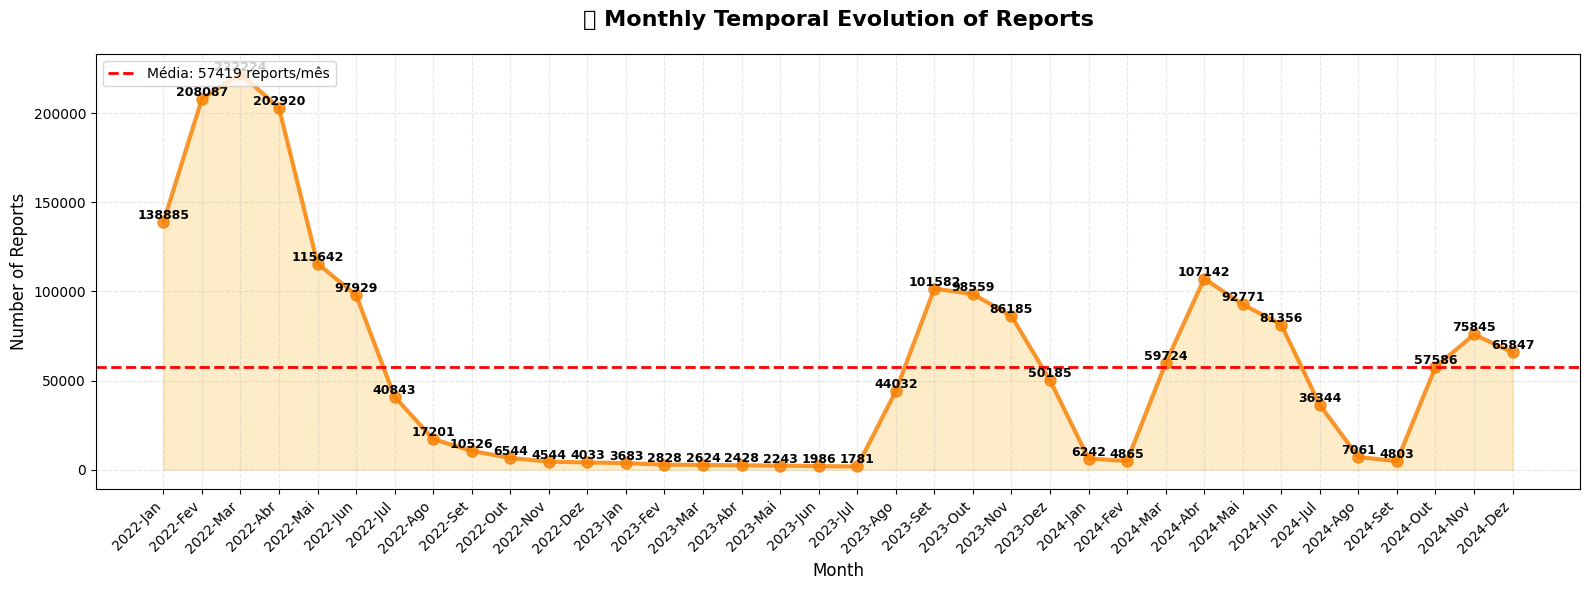


📊 MONTHLY TREND:
   • Evolução mensal mostrando growth/decline patterns
   • Largest fluctuation: 220443 reports


In [38]:
# 📈 GRÁFICO 4: Linha Temporal Mensal
if not df_temporal.empty:
    plt.figure(figsize=(16, 6))
    
    # Plot monthly temporal line
    plt.plot(range(len(reports_por_mes_sorted)), reports_por_mes_sorted['count'], 
             marker='o', linewidth=3, markersize=8, color='#F77F00', alpha=0.8)
    
    # Fill area under curve
    plt.fill_between(range(len(reports_por_mes_sorted)), reports_por_mes_sorted['count'], 
                     alpha=0.3, color='#FCBF49')
    
    plt.title('📈 Monthly Temporal Evolution of Reports', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Month', fontsize=12)
    plt.ylabel('Number of Reports', fontsize=12)
    plt.xticks(range(len(reports_por_mes_sorted)), reports_por_mes_sorted['label'], 
               rotation=45, ha='right')
    
    # Add values on points
    for i, (idx, val) in enumerate(zip(reports_por_mes_sorted.index, reports_por_mes_sorted['count'])):
        plt.text(i, val, f'{int(val)}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    plt.grid(True, alpha=0.3, linestyle='--')
    
    # Add statistics
    avg_reports = reports_por_mes_sorted['count'].mean()
    plt.axhline(y=avg_reports, color='red', linestyle='--', linewidth=2, 
                label=f'Média: {avg_reports:.0f} reports/mês')
    
    plt.legend(loc='upper left', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n📊 MONTHLY TREND:")
    print(f"   • Evolução mensal mostrando growth/decline patterns")
    print(f"   • Largest fluctuation: {reports_por_mes_sorted['count'].max() - reports_por_mes_sorted['count'].min()} reports")


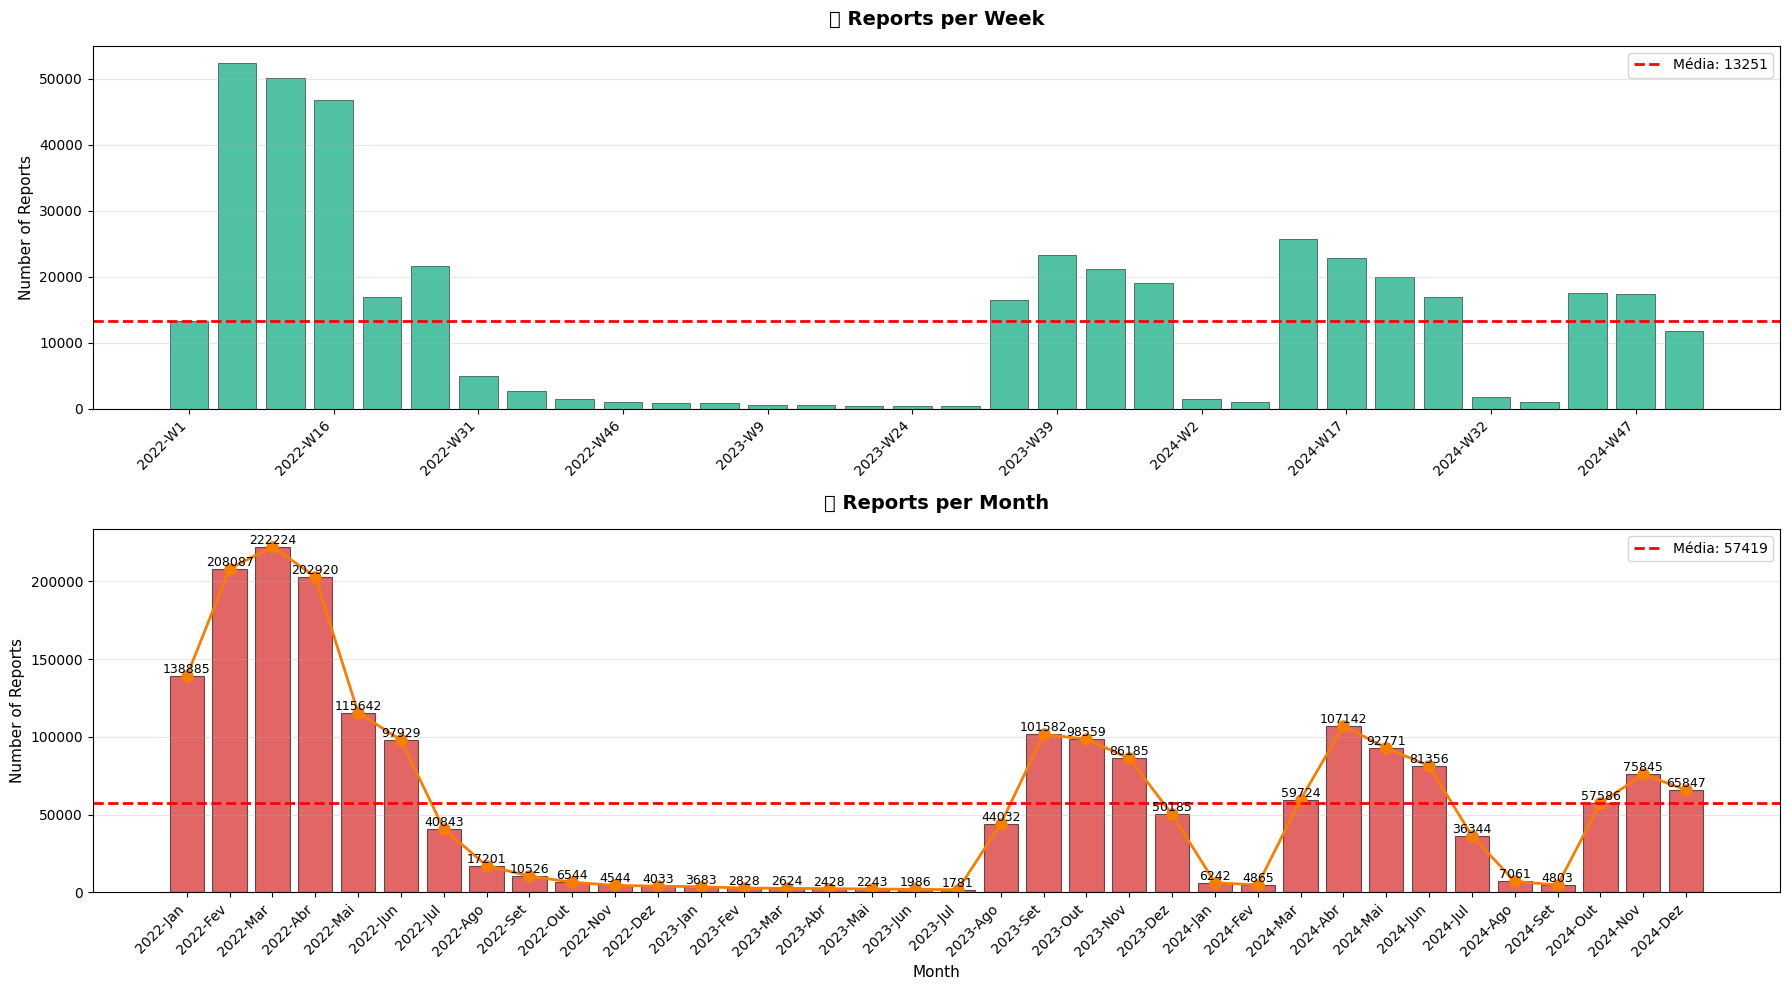


✅ Comparative visualization completed!
   • Top chart: Weekly distribution (barras)
   • Bottom chart: Monthly distribution (barras + linha)


In [39]:
# 📊 GRÁFICO 5: Visual Comparison - Week e Month side by side
if not df_temporal.empty:
    fig, axes = plt.subplots(2, 1, figsize=(18, 10))
    
    # Chart 1: Week (Barras)
    reports_por_semana_display = reports_por_semana_sorted.iloc[::step]
    axes[0].bar(range(len(reports_por_semana_display)), reports_por_semana_display['count'],
                color='#06A77D', alpha=0.7, edgecolor='black', linewidth=0.5)
    axes[0].set_title('📊 Reports per Week', fontsize=14, fontweight='bold', pad=15)
    axes[0].set_ylabel('Number of Reports', fontsize=11)
    axes[0].grid(True, alpha=0.3, axis='y')
    
    x_ticks = range(0, len(reports_por_semana_display), x_labels_step)
    x_labels = [reports_por_semana_display.iloc[i]['label'] for i in x_ticks]
    axes[0].set_xticks(x_ticks)
    axes[0].set_xticklabels(x_labels, rotation=45, ha='right')
    
    # Média
    avg_semana = reports_por_semana_sorted['count'].mean()
    axes[0].axhline(y=avg_semana, color='red', linestyle='--', linewidth=2, 
                    label=f'Média: {avg_semana:.0f}')
    axes[0].legend(loc='upper right')
    
    # Chart 2: Month (Barras com Linha)
    x_pos = range(len(reports_por_mes_sorted))
    axes[1].bar(x_pos, reports_por_mes_sorted['count'],
                color='#D00000', alpha=0.6, edgecolor='black', linewidth=0.8)
    axes[1].plot(x_pos, reports_por_mes_sorted['count'], 
                 marker='o', linewidth=2, color='#F77F00', markersize=8)
    
    axes[1].set_title('📊 Reports per Month', fontsize=14, fontweight='bold', pad=15)
    axes[1].set_xlabel('Month', fontsize=11)
    axes[1].set_ylabel('Number of Reports', fontsize=11)
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels(reports_por_mes_sorted['label'], rotation=45, ha='right')
    axes[1].grid(True, alpha=0.3, axis='y')
    
    # Adicionar valores
    for i, val in enumerate(reports_por_mes_sorted['count']):
        axes[1].text(i, val, f'{int(val)}', ha='center', va='bottom', fontsize=9)
    
    # Média
    avg_mes = reports_por_mes_sorted['count'].mean()
    axes[1].axhline(y=avg_mes, color='red', linestyle='--', linewidth=2, 
                     label=f'Média: {avg_mes:.0f}')
    axes[1].legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()
    
    print("\n✅ Comparative visualization completed!")
    print("   • Top chart: Weekly distribution (barras)")
    print("   • Bottom chart: Monthly distribution (barras + linha)")


## 📋 Temporal Analysis Summary

We analyze the temporal distribution of reports ao longo do período estudado with different granularities:


In [40]:
# Resumo Estatístico da Análise Temporal
if not df_temporal.empty:
    print("📊 STATISTICAL SUMMARY OF TEMPORAL ANALYSIS")
    print("=" * 60)
    
    # Estatísticas Diárias
    print(f"\n📅 DAILY ANALYSIS:")
    print(f"   • Total unique days: {len(reports_por_dia)}")
    print(f"   • Média: {reports_por_dia.mean():.1f} reports/dia")
    print(f"   • Median: {reports_por_dia.median():.1f} reports/dia")
    print(f"   • Standard deviation: {reports_por_dia.std():.1f}")
    print(f"   • Minimum: {reports_por_dia.min()} reports")
    print(f"   • Maximum: {reports_por_dia.max()} reports")
    print(f"   • Date com mais reports: {reports_por_dia.idxmax()}")
    
    # Estatísticas Weekis
    print(f"\n📅 WEEKLY ANALYSIS:")
    print(f"   • Total weeks: {len(reports_por_semana_sorted)}")
    print(f"   • Média: {reports_por_semana_sorted['count'].mean():.1f} reports/semana")
    print(f"   • Median: {reports_por_semana_sorted['count'].median():.1f} reports/semana")
    print(f"   • Standard deviation: {reports_por_semana_sorted['count'].std():.1f}")
    print(f"   • Week with most reports: {reports_por_semana_sorted.loc[reports_por_semana_sorted['count'].idxmax(), 'label']} ({reports_por_semana_sorted['count'].max()} reports)")
    print(f"   • Week with least reports: {reports_por_semana_sorted.loc[reports_por_semana_sorted['count'].idxmin(), 'label']} ({reports_por_semana_sorted['count'].min()} reports)")
    
    # Estatísticas Mensais
    print(f"\n📅 MONTHLY ANALYSIS:")
    print(f"   • Total months: {len(reports_por_mes_sorted)}")
    print(f"   • Média: {reports_por_mes_sorted['count'].mean():.1f} reports/mês")
    print(f"   • Median: {reports_por_mes_sorted['count'].median():.1f} reports/mês")
    print(f"   • Standard deviation: {reports_por_mes_sorted['count'].std():.1f}")
    print(f"   • Month with most reports: {reports_por_mes_sorted.loc[reports_por_mes_sorted['count'].idxmax(), 'label']} ({reports_por_mes_sorted['count'].max()} reports)")
    print(f"   • Month with least reports: {reports_por_mes_sorted.loc[reports_por_mes_sorted['count'].idxmin(), 'label']} ({reports_por_mes_sorted['count'].min()} reports)")
    
    # Tendências
    print(f"\n📈 IDENTIFIED TRENDS:")
    # Calcular crescimento médio
    if len(reports_por_mes_sorted) > 1:
        crescimento = ((reports_por_mes_sorted['count'].iloc[-1] - reports_por_mes_sorted['count'].iloc[0]) / 
                      reports_por_mes_sorted['count'].iloc[0] * 100)
        print(f"   • Variation from first to last month: {crescimento:+.1f}%")
        
        # Identify month with maior crescimento
        crescm_anterior = reports_por_mes_sorted['count'].iloc[:-1].values
        crescm_seguinte = reports_por_mes_sorted['count'].iloc[1:].values
        crescm_percentual = ((crescm_seguinte - crescm_anterior) / crescm_anterior * 100)
        
        max_cresc_mes_idx = np.argmax(crescm_percentual)
        print(f"   • Largest monthly growth: {reports_por_mes_sorted.iloc[max_cresc_mes_idx+1]['label']} ({crescm_percentual[max_cresc_mes_idx]:+.1f}%)")
        
        # Identify month with maior declínio
        min_cresc_mes_idx = np.argmin(crescm_percentual)
        print(f"   • Largest monthly decline: {reports_por_mes_sorted.iloc[min_cresc_mes_idx+1]['label']} ({crescm_percentual[min_cresc_mes_idx]:+.1f}%)")
    
    print(f"\n✅ Detailed temporal analysis completed!")
    print("=" * 60)


📊 STATISTICAL SUMMARY OF TEMPORAL ANALYSIS

📅 DAILY ANALYSIS:
   • Total unique days: 1096
   • Média: 1886.0 reports/dia
   • Median: 747.0 reports/dia
   • Standard deviation: 2171.7
   • Minimum: 51 reports
   • Maximum: 7725 reports
   • Date com mais reports: 2022-02-02

📅 WEEKLY ANALYSIS:
   • Total weeks: 156
   • Média: 13250.5 reports/semana
   • Median: 5165.5 reports/semana
   • Standard deviation: 15142.4
   • Week with most reports: 2022-W5 (52772 reports)
   • Week with least reports: 2023-W30 (381 reports)

📅 MONTHLY ANALYSIS:
   • Total months: 36
   • Média: 57418.9 reports/mês
   • Median: 42437.5 reports/mês
   • Standard deviation: 62489.9
   • Month with most reports: 2022-Mar (222224 reports)
   • Month with least reports: 2023-Jul (1781 reports)

📈 IDENTIFIED TRENDS:
   • Variation from first to last month: -52.6%
   • Largest monthly growth: 2023-Ago (+2372.3%)
   • Largest monthly decline: 2024-Jan (-87.6%)

✅ Detailed temporal analysis completed!


## 🦠 Análise de Sintomas por Mês

Vamos extrair e analisar os sintomas únicos relatados em cada mês.


In [41]:
# Processar sintomas únicos por mês
if not df_temporal.empty and 'report_symptoms' in df_temporal.columns:
    # Criar coluna de ano-mês
    df_temporal['ano_mes'] = df_temporal['report_created_at'].dt.to_period('M').astype(str)
    
    # Filtrar apenas registros que têm sintomas
    df_com_sintomas = df_temporal[df_temporal['report_symptoms'].notna()].copy()
    
    # Extrair sintomas únicos por mês
    sintomas_por_mes = {}
    
    for mes in df_com_sintomas['ano_mes'].unique():
        # Filtrar registros do mês
        registros_mes = df_com_sintomas[df_com_sintomas['ano_mes'] == mes]
        
        # Extrair todos os sintomas únicos do mês
        sintomas_mes = set()
        for sintoma_str in registros_mes['report_symptoms'].dropna():
            if pd.notna(sintoma_str) and str(sintoma_str).strip():
                # Limpar e extrair sintomas individuais
                sintomas = str(sintoma_str).strip()
                # Dividir por linhas e remover valores vazios
                sintoma_list = [s.strip() for s in sintomas.split('\n') if s.strip() and s.strip() not in ['---', '-']]
                sintomas_mes.update(sintoma_list)
        
        sintomas_por_mes[mes] = {
            'sintomas_unicos': sorted(list(sintomas_mes)),
            'total_sintomas_unicos': len(sintomas_mes),
            'total_reportes': len(registros_mes)
        }
    
    print(f"✅ Sintomas processados para {len(sintomas_por_mes)} meses")
    print(f"   • Total de reportes com sintomas: {len(df_com_sintomas):,}")


✅ Sintomas processados para 36 meses
   • Total de reportes com sintomas: 21,061


In [42]:
# Salvar sintomas únicos por mês em JSON
import json
import os

# Criar diretório se não existir
output_dir = '../data/processed'
os.makedirs(output_dir, exist_ok=True)

# Salvar JSON
output_file = os.path.join(output_dir, 'sintomas_unicos_por_mes.json')
with open(output_file, 'w', encoding='utf-8') as f:
    json.dump(sintomas_por_mes, f, ensure_ascii=False, indent=2)

print(f"✅ Dados salvos em: {output_file}")
print(f"   • Total de meses: {len(sintomas_por_mes)}")
print(f"   • Estrutura: ano-mês -> sintomas_unicos, total_sintomas_unicos, total_reportes")


✅ Dados salvos em: ../data/processed/sintomas_unicos_por_mes.json
   • Total de meses: 36
   • Estrutura: ano-mês -> sintomas_unicos, total_sintomas_unicos, total_reportes


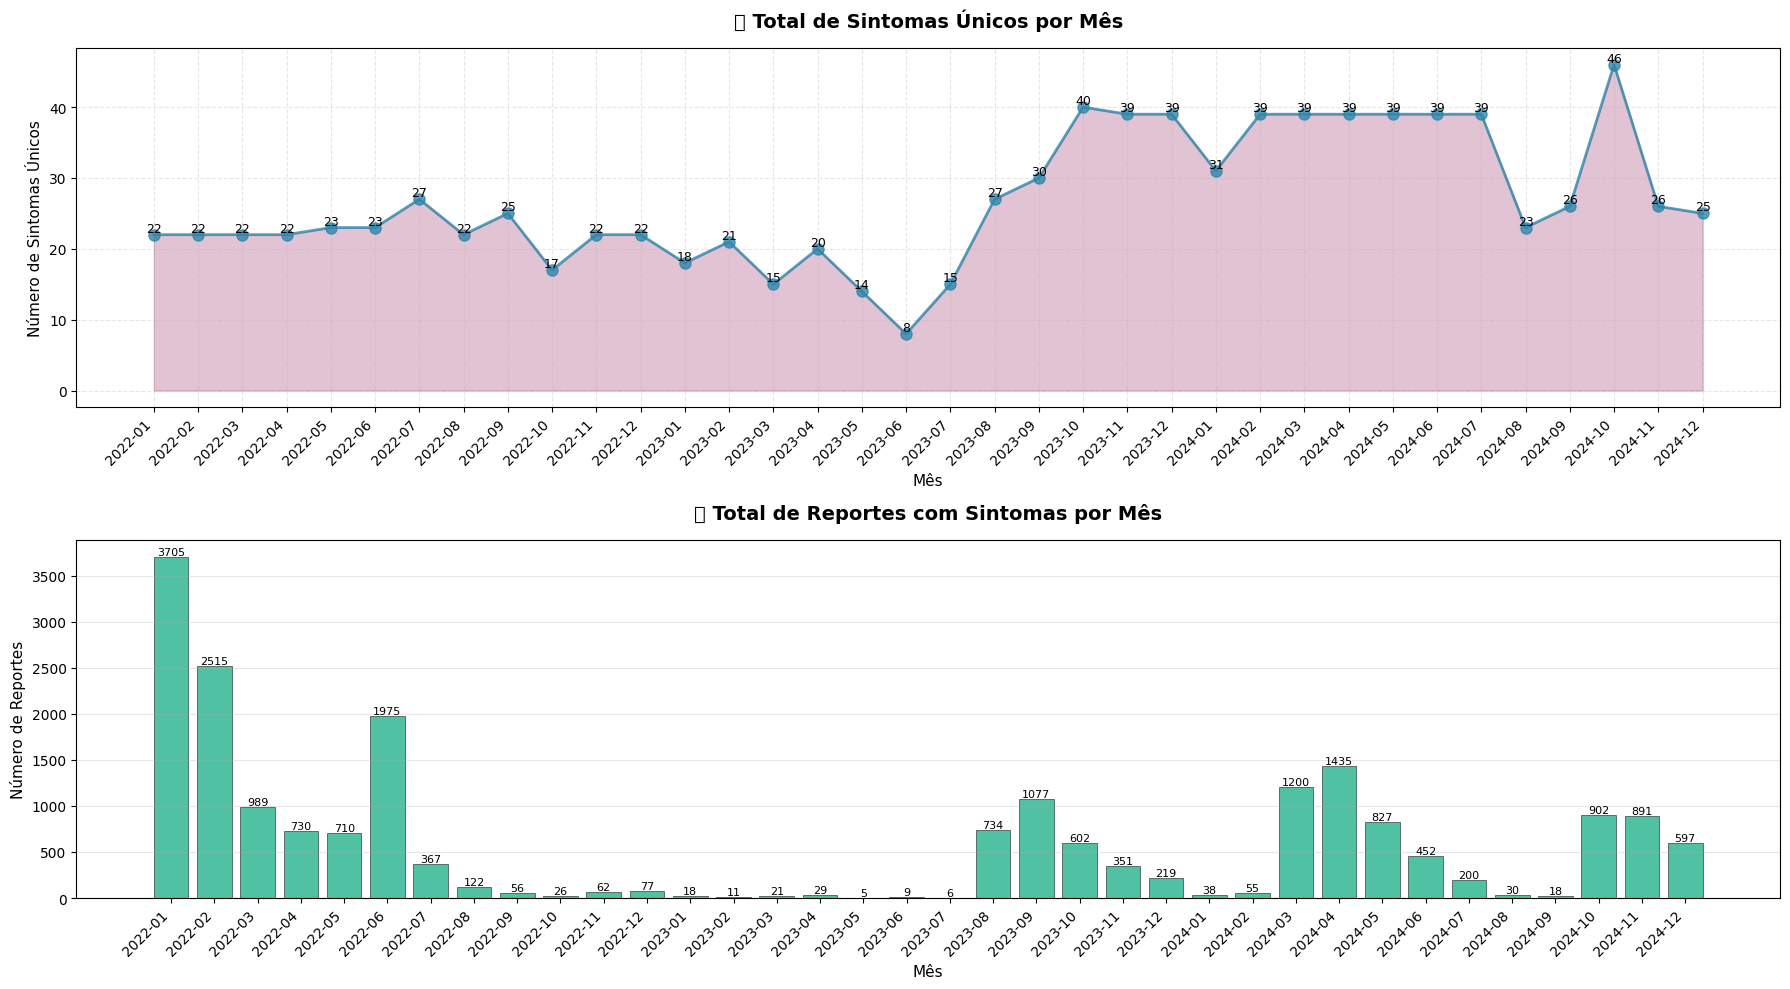


✅ Visualização criada!
   • Gráfico superior: Evolução do número de sintomas únicos por mês
   • Gráfico inferior: Evolução do número de reportes com sintomas por mês


In [43]:
# Visualização: Sintomas únicos e reportes por mês
if 'sintomas_por_mes' in locals():
    # Preparar dados para visualização
    meses = sorted(sintomas_por_mes.keys())
    total_sintomas_unicos = [sintomas_por_mes[mes]['total_sintomas_unicos'] for mes in meses]
    total_reportes = [sintomas_por_mes[mes]['total_reportes'] for mes in meses]
    
    # Criar figura com dois gráficos
    fig, axes = plt.subplots(2, 1, figsize=(18, 10))
    
    # Gráfico 1: Total de sintomas únicos por mês
    axes[0].plot(range(len(meses)), total_sintomas_unicos, 
                 marker='o', linewidth=2, markersize=8, color='#2E86AB', alpha=0.8)
    axes[0].fill_between(range(len(meses)), total_sintomas_unicos, 
                         alpha=0.3, color='#A23B72')
    axes[0].set_title('📊 Total de Sintomas Únicos por Mês', fontsize=14, fontweight='bold', pad=15)
    axes[0].set_xlabel('Mês', fontsize=11)
    axes[0].set_ylabel('Número de Sintomas Únicos', fontsize=11)
    axes[0].set_xticks(range(len(meses)))
    axes[0].set_xticklabels(meses, rotation=45, ha='right')
    axes[0].grid(True, alpha=0.3, linestyle='--')
    
    # Adicionar valores nos pontos
    for i, val in enumerate(total_sintomas_unicos):
        axes[0].text(i, val, f'{val}', ha='center', va='bottom', fontsize=9)
    
    # Gráfico 2: Total de reportes com sintomas por mês
    axes[1].bar(range(len(meses)), total_reportes, 
                color='#06A77D', alpha=0.7, edgecolor='black', linewidth=0.5)
    axes[1].set_title('📊 Total de Reportes com Sintomas por Mês', fontsize=14, fontweight='bold', pad=15)
    axes[1].set_xlabel('Mês', fontsize=11)
    axes[1].set_ylabel('Número de Reportes', fontsize=11)
    axes[1].set_xticks(range(len(meses)))
    axes[1].set_xticklabels(meses, rotation=45, ha='right')
    axes[1].grid(True, alpha=0.3, axis='y')
    
    # Adicionar valores nas barras
    for i, val in enumerate(total_reportes):
        axes[1].text(i, val, f'{val}', ha='center', va='bottom', fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    print("\n✅ Visualização criada!")
    print(f"   • Gráfico superior: Evolução do número de sintomas únicos por mês")
    print(f"   • Gráfico inferior: Evolução do número de reportes com sintomas por mês")


In [44]:
# Estatísticas dos sintomas por mês
if 'sintomas_por_mes' in locals():
    print("📊 ESTATÍSTICAS DOS SINTOMAS POR MÊS")
    print("=" * 60)
    
    # Calcular estatísticas gerais
    todos_sintomas = set()
    for mes in sintomas_por_mes:
        todos_sintomas.update(sintomas_por_mes[mes]['sintomas_unicos'])
    
    total_reportes_sintomas = sum([sintomas_por_mes[mes]['total_reportes'] for mes in sintomas_por_mes])
    
    print(f"\n📊 RESUMO GERAL:")
    print(f"   • Total de sintomas únicos registrados (todos os meses): {len(todos_sintomas)}")
    print(f"   • Total de reportes com sintomas: {total_reportes_sintomas:,}")
    print(f"   • Média de sintomas únicos por mês: {np.mean([sintomas_por_mes[mes]['total_sintomas_unicos'] for mes in sintomas_por_mes]):.1f}")
    print(f"   • Média de reportes com sintomas por mês: {np.mean([sintomas_por_mes[mes]['total_reportes'] for mes in sintomas_por_mes]):.1f}")
    
    print(f"\n📈 TOP 5 MESES COM MAIS SINTOMAS ÚNICOS:")
    meses_ordenados = sorted(sintomas_por_mes.items(), key=lambda x: x[1]['total_sintomas_unicos'], reverse=True)
    for i, (mes, dados) in enumerate(meses_ordenados[:5], 1):
        print(f"   {i}. {mes}: {dados['total_sintomas_unicos']} sintomas únicos, {dados['total_reportes']} reportes")
    
    print(f"\n📈 TOP 5 MESES COM MAIS REPORTES:")
    meses_ordenados_reportes = sorted(sintomas_por_mes.items(), key=lambda x: x[1]['total_reportes'], reverse=True)
    for i, (mes, dados) in enumerate(meses_ordenados_reportes[:5], 1):
        print(f"   {i}. {mes}: {dados['total_reportes']} reportes, {dados['total_sintomas_unicos']} sintomas únicos")
    
    print(f"\n✅ Análise de sintomas por mês concluída!")
    print("=" * 60)


📊 ESTATÍSTICAS DOS SINTOMAS POR MÊS

📊 RESUMO GERAL:
   • Total de sintomas únicos registrados (todos os meses): 61
   • Total de reportes com sintomas: 21,061
   • Média de sintomas únicos por mês: 26.8
   • Média de reportes com sintomas por mês: 585.0

📈 TOP 5 MESES COM MAIS SINTOMAS ÚNICOS:
   1. 2024-10: 46 sintomas únicos, 902 reportes
   2. 2023-10: 40 sintomas únicos, 602 reportes
   3. 2023-11: 39 sintomas únicos, 351 reportes
   4. 2023-12: 39 sintomas únicos, 219 reportes
   5. 2024-02: 39 sintomas únicos, 55 reportes

📈 TOP 5 MESES COM MAIS REPORTES:
   1. 2022-01: 3705 reportes, 22 sintomas únicos
   2. 2022-02: 2515 reportes, 22 sintomas únicos
   3. 2022-06: 1975 reportes, 23 sintomas únicos
   4. 2024-04: 1435 reportes, 39 sintomas únicos
   5. 2024-03: 1200 reportes, 39 sintomas únicos

✅ Análise de sintomas por mês concluída!


In [45]:
# Identificar sintomas que aparecem em TODOS os meses
if 'sintomas_por_mes' in locals():
    print("🔍 Identificando sintomas que aparecem consistentemente em todos os meses...")
    
    # Obter conjunto de todos os sintomas de cada mês
    todos_conjuntos_sintomas = [set(sintomas_por_mes[mes]['sintomas_unicos']) for mes in sintomas_por_mes]
    
    # Sintomas que aparecem em TODOS os meses
    sintomas_consistentes = set.intersection(*todos_conjuntos_sintomas) if todos_conjuntos_sintomas else set()
    
    # Sintomas que aparecem apenas em alguns meses
    todos_sintomas = set.union(*todos_conjuntos_sintomas) if todos_conjuntos_sintomas else set()
    sintomas_esporadicos = todos_sintomas - sintomas_consistentes
    
    # Contar frequência de cada sintoma (em quantos meses apareceu)
    frequencia_sintomas = {}
    for sintoma in todos_sintomas:
        frequencia = sum(1 for mes in sintomas_por_mes if sintoma in sintomas_por_mes[mes]['sintomas_unicos'])
        frequencia_sintomas[sintoma] = frequencia
    
    # Criar estrutura de dados
    sintomas_completo = {
        'sintomas_consistentes': sorted(list(sintomas_consistentes)),
        'total_sintomas_consistentes': len(sintomas_consistentes),
        'sintomas_esporadicos': sorted(list(sintomas_esporadicos)),
        'total_sintomas_esporadicos': len(sintomas_esporadicos),
        'frequencia_por_sintoma': {k: v for k, v in sorted(frequencia_sintomas.items(), key=lambda x: x[1], reverse=True)},
        'total_meses_analisados': len(sintomas_por_mes),
        'total_sintomas_unicos_geral': len(todos_sintomas)
    }
    
    print(f"✅ Análise concluída:")
    print(f"   • Sintomas consistentes (aparecem em TODOS os meses): {len(sintomas_consistentes)}")
    print(f"   • Sintomas esporádicos (aparecem apenas em alguns meses): {len(sintomas_esporadicos)}")
    print(f"   • Total de sintomas únicos identificados: {len(todos_sintomas)}")
    print(f"   • Período analisado: {len(sintomas_por_mes)} meses")


🔍 Identificando sintomas que aparecem consistentemente em todos os meses...
✅ Análise concluída:
   • Sintomas consistentes (aparecem em TODOS os meses): 0
   • Sintomas esporádicos (aparecem apenas em alguns meses): 61
   • Total de sintomas únicos identificados: 61
   • Período analisado: 36 meses


In [46]:
# Salvar sintomas consistentes e análise completa
if 'sintomas_completo' in locals():
    # Arquivo 1: Sintomas consistentes apenas
    output_file_consistentes = os.path.join(output_dir, 'sintomas_consistentes.json')
    dados_consistentes = {
        'sintomas': sintomas_completo['sintomas_consistentes'],
        'total': sintomas_completo['total_sintomas_consistentes'],
        'descricao': 'Sintomas que aparecem em TODOS os meses do período analisado'
    }
    
    with open(output_file_consistentes, 'w', encoding='utf-8') as f:
        json.dump(dados_consistentes, f, ensure_ascii=False, indent=2)
    
    # Arquivo 2: Análise completa de sintomas
    output_file_completo = os.path.join(output_dir, 'analise_completa_sintomas.json')
    
    with open(output_file_completo, 'w', encoding='utf-8') as f:
        json.dump(sintomas_completo, f, ensure_ascii=False, indent=2)
    
    print(f"\n✅ Arquivos salvos:")
    print(f"   • {output_file_consistentes}")
    print(f"      → Sintomas que aparecem em TODOS os meses ({len(sintomas_completo['sintomas_consistentes'])} sintomas)")
    print(f"   • {output_file_completo}")
    print(f"      → Análise completa: consistentes, esporádicos e frequências")
    
    # Mostrar sintomas consistentes
    if sintomas_completo['total_sintomas_consistentes'] > 0:
        print(f"\n📋 SINTOMAS CONSISTENTES (aparecem em todos os meses):")
        for i, sintoma in enumerate(sintomas_completo['sintomas_consistentes'], 1):
            print(f"   {i}. {sintoma}")



✅ Arquivos salvos:
   • ../data/processed/sintomas_consistentes.json
      → Sintomas que aparecem em TODOS os meses (0 sintomas)
   • ../data/processed/analise_completa_sintomas.json
      → Análise completa: consistentes, esporádicos e frequências
